In [2]:
from pathlib import Path

import cv2
import numpy as np

import torch
import torch.nn as nn

from PIL import Image

import torchvision.models as models
from torchvision.models import ResNet50_Weights

In [3]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "raw"
    / "UAH-DRIVESET-v1"
)

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = ResNet50_Weights.DEFAULT

resnet = models.resnet50(
    weights=weights
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


In [6]:
feature_extractor = nn.Sequential(
    *list(resnet.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [7]:
transform = weights.transforms()

video_paths = sorted(DATASET_PATH.rglob("*.mp4"))

print(len(video_paths))

40


In [8]:
video_paths = sorted(
    DATASET_PATH.rglob("*.mp4")
)

print(len(video_paths))

40


In [9]:
def sample_frames_from_window(
    video_path,
    start_second,
    window_size=12,
):
    """
    Sample one frame per second from a time window.

    Returns
    -------
    frames : list
        RGB frames
    """

    cap = cv2.VideoCapture(str(video_path))

    fps = int(cap.get(cv2.CAP_PROP_FPS))

    frames = []

    for second in range(
        start_second,
        start_second + window_size,
    ):

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            second * fps,
        )

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        frames.append(frame)

    cap.release()

    return frames

In [10]:
frames = sample_frames_from_window(
    video_paths[0],
    start_second=0,
)

print(len(frames))

12


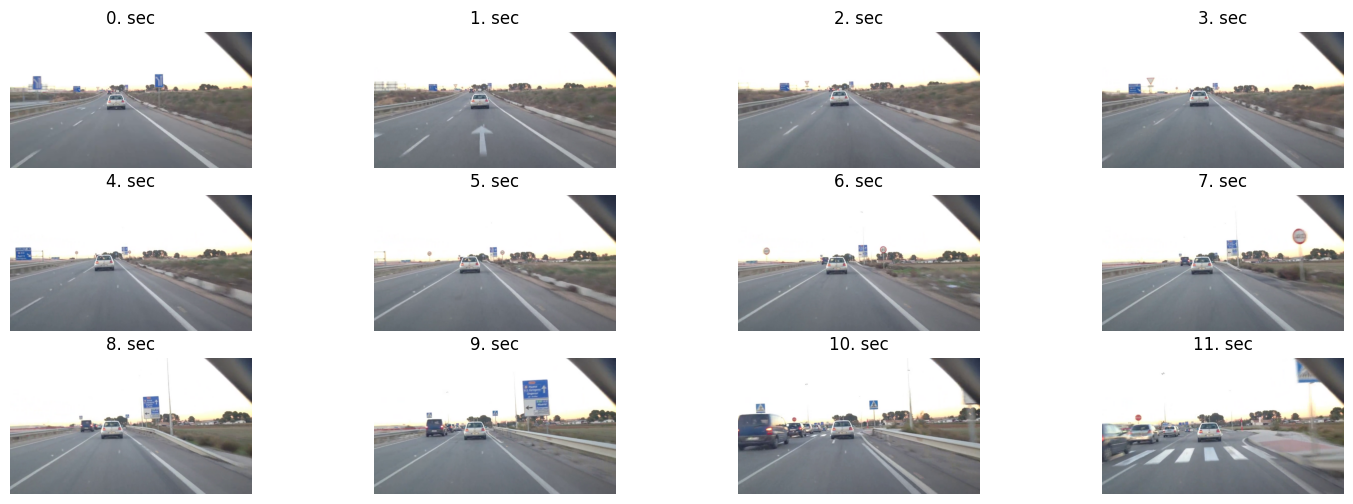

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

for i, frame in enumerate(frames):

    plt.subplot(3,4,i+1)

    plt.imshow(frame)

    plt.title(f"{i}. sec")

    plt.axis("off")

plt.show()

In [12]:
def extract_sequence_feature(
    frames,
    feature_extractor,
    transform,
    device,
):
    """
    Extract one ResNet50 feature
    for every frame in a sequence.

    Returns
    -------
    np.ndarray
        Shape = (12, 2048)
    """

    features = []

    for frame in frames:

        image = Image.fromarray(frame)

        input_tensor = transform(image)

        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():

            feature = feature_extractor(input_tensor)

        feature = feature.squeeze().cpu().numpy()

        features.append(feature)

    features = np.stack(features)

    return features

In [13]:
sequence_feature = extract_sequence_feature(
    frames,
    feature_extractor,
    transform,
    device,
)

print(sequence_feature.shape)

(12, 2048)


In [14]:
print(sequence_feature[:20])

[[0.         0.         0.03724733 ... 0.         0.         0.0117177 ]
 [0.         0.         0.         ... 0.07215611 0.00591422 0.        ]
 [0.         0.         0.         ... 0.03544525 0.         0.01274901]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.02096557 ... 0.01155738 0.         0.        ]
 [0.00407104 0.         0.         ... 0.01294984 0.         0.        ]]


In [15]:
cap = cv2.VideoCapture(str(video_paths[0]))

fps = cap.get(cv2.CAP_PROP_FPS)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = frame_count / fps

cap.release()

print("FPS:", fps)
print("Duration:", duration)
print("Duration (int):", int(duration))

FPS: 29.97305651865157
Duration: 638.3733333333333
Duration (int): 638


In [16]:
WINDOW_SIZE = 12
STRIDE_SECONDS = 1

num_video_sequences = (
    int(duration)
    - WINDOW_SIZE
) // STRIDE_SECONDS + 1

print(num_video_sequences)

627


In [17]:
import sys

sys.path.append("/content/drive/MyDrive/UAH_Project/src")

from preprocessor import merge_trip, clean_trip

In [18]:
trip_path = video_paths[0].parent

merged_df = merge_trip(trip_path)
clean_df = clean_trip(merged_df)

print(len(clean_df))

6170


In [19]:
sensor_sequences = (
    len(clean_df) - 120
) // 10 + 1

print(sensor_sequences)

606


In [20]:
from tqdm import tqdm

In [21]:
def extract_video_sequence_features(
    video_path,
    num_sequences,
    feature_extractor,
    transform,
    device,
):
    """
    Extract one ResNet50 feature for every
    12-second sequence in a video.
    """

    all_features = []

    for start_second in tqdm(
        range(num_sequences),
        leave=False,
    ):

        # 12 frame al
        frames = sample_frames_from_window(
            video_path,
            start_second=start_second,
            window_size=12,
        )

        # Eğer video bittiyse çık
        if len(frames) < 12:
            print(
                f"{video_path.name}: video ended at sequence {start_second}"
            )
            break

        # ResNet feature çıkar
        feature = extract_sequence_feature(
            frames,
            feature_extractor,
            transform,
            device,
        )

        all_features.append(feature)

    # Güvenlik kontrolü
    if len(all_features) == 0:
        raise RuntimeError(
            f"No features extracted from {video_path.name}"
        )

    all_features = np.stack(all_features)

    return all_features

In [22]:
sensor_sequences = 606

In [23]:
video_features = extract_video_sequence_features(
    video_paths[0],
    sensor_sequences,
    feature_extractor,
    transform,
    device,
)

print(video_features.shape)

(606, 12, 2048)


In [24]:
print(video_features[0][:10])

print(video_features[1][:10])

print(video_features[2][:10])

[[0.         0.         0.03724733 ... 0.         0.         0.0117177 ]
 [0.         0.         0.         ... 0.07215611 0.00591422 0.        ]
 [0.         0.         0.         ... 0.03544525 0.         0.01274901]
 ...
 [0.         0.00347971 0.00516139 ... 0.         0.         0.        ]
 [0.         0.         0.03911123 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
[[0.         0.         0.         ... 0.07215611 0.00591422 0.        ]
 [0.         0.         0.         ... 0.03544525 0.         0.01274901]
 [0.         0.         0.         ... 0.32962856 0.         0.        ]
 ...
 [0.         0.         0.03911123 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.02096557 ... 0.01155738 0.         0.        ]]
[[0.         0.         0.         ... 0.03544525 0.         0.01274901]
 [0.         0.         0.         ... 

In [25]:
OUTPUT_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "video_features_temporal"
)

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

print(OUTPUT_PATH)

/content/drive/MyDrive/UAH_Project/datasets/processed/video_features_temporal


In [26]:
def process_all_videos(
    video_paths,
    feature_extractor,
    transform,
    device,
    output_path,
):
    """
    Extract sequence features from every video and save them.
    """

    for video_path in tqdm(video_paths):

        try:

            # -------------------------------------------------
            # Daha önce işlendiyse atla
            # -------------------------------------------------

            save_name = video_path.stem + ".npy"
            save_path = output_path / save_name

            if save_path.exists():
                print(f"Skipping -> {save_name}")
                continue

            print(f"\nProcessing -> {video_path.name}")

            # -------------------------------------------------
            # Sensör sequence sayısı
            # -------------------------------------------------

            trip_path = video_path.parent

            merged_df = merge_trip(trip_path)
            clean_df = clean_trip(merged_df)

            sensor_sequences = (
                len(clean_df) - 120
            ) // 10 + 1

            # -------------------------------------------------
            # Video sequence sayısı
            # -------------------------------------------------

            cap = cv2.VideoCapture(str(video_path))

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            duration = frame_count / fps

            cap.release()

            video_sequences = int(duration) - 12 + 1

            # İkisinden kısa olanı kullan
            num_sequences = min(
                sensor_sequences,
                video_sequences,
            )

            print(
                f"Sensor={sensor_sequences} | "
                f"Video={video_sequences} | "
                f"Using={num_sequences}"
            )

            # -------------------------------------------------
            # Feature extraction
            # -------------------------------------------------

            video_features = extract_video_sequence_features(
                video_path,
                num_sequences,
                feature_extractor,
                transform,
                device,
            )

            # -------------------------------------------------
            # Kaydet
            # -------------------------------------------------

            np.save(
                save_path,
                video_features,
            )

            print(
                f"Saved -> {save_name} "
                f"{video_features.shape}"
            )

        except Exception as e:

            print(f"\nERROR -> {video_path.name}")
            print(e)

            continue

In [ ]:
process_all_videos(
    video_paths,
    feature_extractor,
    transform,
    device,
    OUTPUT_PATH,
)

  2%|▎         | 1/40 [00:00<00:08,  4.36it/s]

Skipping -> 20151110175712-16km-D1-NORMAL1-SECONDARY.npy
Skipping -> 20151110180846-16km-D1-NORMAL2-SECONDARY.npy
Skipping -> 20151111123123-25km-D1-NORMAL-MOTORWAY.npy
Skipping -> 20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.npy
Skipping -> 20151111132343-25km-D1-DROWSY-MOTORWAY.npy
Skipping -> 20151111134542-16km-D1-AGGRESSIVE-SECONDARY..npy
Skipping -> 20151111135605-13km-D1-DROWSY-SECONDARY.npy
Skipping -> 20151120131704-26km-D2-NORMAL-MOTORWAY.npy
Skipping -> 20151120133457-26km-D2-AGGRESSIVE-MOTORWAY.npy
Skipping -> 20151120135150-25km-D2-DROWSY-MOTORWAY.npy
Skipping -> 20151120160903-16km-D2-NORMAL1-SECONDARY.npy
Skipping -> 20151120162104-17km-D2-NORMAL2-SECONDARY.npy
Skipping -> 20151120163335-16km-D2-AGGRESSIVE-SECONDARY.npy
Skipping -> 20151120165604-16km-D2-DROWSY-SECONDARY.npy
Skipping -> 20151126110501-26km-D3-NORMAL-MOTORWAY.npy
Skipping -> 20151126113753-26km-D3-DROWSY-MOTORWAY.npy
Skipping -> 20151126124207-16km-D3-NORMAL1-SECONDARY.npy
Skipping -> 20151126125500-16km-D3


 48%|████▊     | 19/40 [13:52<15:35, 44.54s/it]

Saved -> 20151126130708-16km-D3-AGGRESSIVE-SECONDARY.npy (667, 12, 2048)

Processing -> 20151126132012-16km-D3-DROWSY-SECONDARY.mp4
Sensor=651 | Video=555 | Using=555



 50%|█████     | 20/40 [24:22<28:41, 86.09s/it]

Saved -> 20151126132012-16km-D3-DROWSY-SECONDARY.npy (555, 12, 2048)

Processing -> 20151126134731-26km-D3-AGGRESSIVE-MOTORWAY.mp4
Sensor=824 | Video=845 | Using=824



 52%|█████▎    | 21/40 [39:31<51:14, 161.83s/it]

Saved -> 20151126134731-26km-D3-AGGRESSIVE-MOTORWAY.npy (824, 12, 2048)

Processing -> 20151203171759-16km-D4-NORMAL1-SECONDARY.mp4
Sensor=718 | Video=728 | Using=718



 24%|██▎       | 170/718 [02:49<08:05,  1.13it/s]

In [ ]:
saved_files = sorted(OUTPUT_PATH.glob("*.npy"))

print("Kaydedilen dosya sayısı:", len(saved_files))

for f in saved_files:
    print(f.name)

In [ ]:
saved_files = sorted(OUTPUT_PATH.glob("*.npy"))
print(len(saved_files))